# PathLDM - NIPA 병리 이미지 학습

NIPA 병리 패치 이미지(1024x1024, JPEG)를 이용한 **Latent Diffusion Model (LDM)** 학습  
- 데이터: `../../data/NIPA/origin/` (클래스별 폴더)
- 모델 저장: `../../model/NIPA/pathldm/`
- 참고 코드: `latent-diffusion-main/` (LDM UNetModel + ClassEmbedder)
- First Stage VAE: `stabilityai/sd-vae-ft-mse` (diffusers)
- 학습 이미지 크기: 1024×1024 → latent 128×128×4 (VAE f8 압축)

In [1]:
# ── 필수 패키지 설치 (최초 1회만 실행) ──────────────────────────────────────
# urban 환경 기준 — accelerate, diffusers, omegaconf 가 없으면 설치합니다.
import subprocess, sys

def install_if_missing(package, import_name=None):
    import_name = import_name or package
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_if_missing("accelerate")
install_if_missing("diffusers")
install_if_missing("omegaconf")
install_if_missing("pytorch-lightning", "pytorch_lightning")

print("All required packages are available.")

/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All required packages are available.


## 1. 환경 설정 및 Import

In [2]:
import os
import sys
import math
import random
from pathlib import Path
from glob import glob

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW, lr_scheduler
import torchvision.transforms as T
from torchvision import utils as vutils
from PIL import Image
from tqdm import tqdm
from accelerate import Accelerator
from diffusers import AutoencoderKL

# LDM 모듈 경로 추가 (latent-diffusion-main/ 기준 실행)
LDM_DIR = os.path.abspath(".")
if LDM_DIR not in sys.path:
    sys.path.insert(0, LDM_DIR)

from ldm.modules.diffusionmodules.openaimodel import UNetModel
from ldm.modules.diffusionmodules.util import make_beta_schedule
from ldm.modules.ema import LitEma  # LDM 자체 EMA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "CPU only")

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


## 2. 설정값 정의

In [3]:
# 경로
DATA_ROOT = "../../../data/NIPA/origin"
MODEL_SAVE_DIR = "../../../model/NIPA/pathldm"
RESULTS_DIR = os.path.join(MODEL_SAVE_DIR, "results")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# 이미지 & Latent 크기
IMAGE_SIZE = 1024       # 원본 1024×1024 그대로 사용 (VAE f8 → latent 128×128)
LATENT_SIZE = 128       # IMAGE_SIZE // 8 (SD VAE는 8배 압축)
LATENT_CHANNELS = 4     # SD VAE latent channels
SCALE_FACTOR = 0.18215  # SD VAE 표준 scale factor

# LDM UNet 하이퍼파라미터 (cin256 config 기반)
MODEL_CHANNELS = 256
CHANNEL_MULT = (1, 2, 4)
ATTENTION_RESOLUTIONS = (4,2)   # latent 32x32, 64x64, 128x128 에서 attention
NUM_RES_BLOCKS = 2
NUM_HEAD_CHANNELS = 32
CONTEXT_DIM = 512       # ClassEmbedder 임베딩 차원
TRANSFORMER_DEPTH = 1

# Diffusion 스케줄 (LDM latent 공간용 lin schedule)
TIMESTEPS = 1000
SAMPLING_TIMESTEPS = 50  # DDIM steps
LINEAR_START = 0.0015
LINEAR_END = 0.0195

# 학습 하이퍼파라미터
BATCH_SIZE = 1             # 1024×1024 → latent 128×128, VRAM 절약
LEARNING_RATE = 1e-4
TRAIN_NUM_STEPS = 250000
SAVE_SAMPLE_EVERY = 5000
SAVE_LOSS_EVERY = 100
GRADIENT_ACCUMULATE_EVERY = 4  # 실질 batch size = 4
NUM_SAMPLES = 4
NUM_WORKERS = 4
TRAIN_RATIO = 0.9
COND_DROP_PROB = 0.1    # classifier-free guidance: unconditional 비율

# 클래스 정보 (index 0 = unconditional)
CLASS_NAMES = sorted(os.listdir(DATA_ROOT))
NUM_CLASSES = len(CLASS_NAMES)
# idx=0: unconditional(null), idx=1~N: 각 클래스
CLASS_TO_IDX = {name: idx + 1 for idx, name in enumerate(CLASS_NAMES)}
N_EMBED = NUM_CLASSES + 1  # embedding 수 (0 포함)

print(f"클래스 수: {NUM_CLASSES}")
print(f"클래스 목록: {CLASS_TO_IDX}")
print(f"Image size: {IMAGE_SIZE}×{IMAGE_SIZE} → Latent: {LATENT_SIZE}×{LATENT_SIZE}×{LATENT_CHANNELS}")
print(f"Effective batch size: {BATCH_SIZE} × {GRADIENT_ACCUMULATE_EVERY} = {BATCH_SIZE * GRADIENT_ACCUMULATE_EVERY}")

클래스 수: 9
클래스 목록: {'BRDC': 1, 'BRID': 2, 'BRIL': 3, 'BRLC': 4, 'BRNT': 5, 'STDI': 6, 'STIN': 7, 'STMX': 8, 'STNT': 9}
Image size: 1024×1024 → Latent: 128×128×4
Effective batch size: 1 × 4 = 4


In [4]:
CLASS_NAMES

['BRDC', 'BRID', 'BRIL', 'BRLC', 'BRNT', 'STDI', 'STIN', 'STMX', 'STNT']

## 3. 데이터셋 정의

- 1024×1024 JPEG를 256×256으로 리사이즈 후 학습
- VAE 입력 정규화: `[0,1] → [-1,1]`
- `COND_DROP_PROB` 확률로 클래스 레이블을 0(unconditional)으로 드롭 → Classifier-Free Guidance 지원

In [5]:
class NIPAPathologyDataset(Dataset):
    """NIPA 병리 패치 이미지 데이터셋 (클래스별 폴더 구조)"""

    def __init__(self, file_list, labels, image_size=256, cond_drop_prob=0.1, is_train=True):
        self.file_list = file_list
        self.labels = labels
        self.cond_drop_prob = cond_drop_prob
        self.is_train = is_train

        base_transforms = [
            T.Resize((image_size, image_size)),
            T.ToTensor(),  # [0, 1]
        ]
        if is_train:
            base_transforms += [
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
            ]
        self.transform = T.Compose(base_transforms)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img = Image.open(self.file_list[idx]).convert("RGB")
        img = self.transform(img)  # [3, H, W], [0,1]

        label = self.labels[idx]
        # Classifier-Free Guidance: 일정 확률로 unconditional (label=0)
        if self.is_train and random.random() < self.cond_drop_prob:
            label = 0

        return img, label


def build_datasets(data_root, class_to_idx, image_size=256, train_ratio=0.9, cond_drop_prob=0.1):
    """클래스별 폴더에서 train/val 데이터셋 생성"""
    all_files, all_labels = [], []

    for class_name, class_idx in class_to_idx.items():
        class_dir = os.path.join(data_root, class_name)
        if not os.path.isdir(class_dir):
            continue
        img_files = sorted(
            glob(os.path.join(class_dir, "*.jpeg")) +
            glob(os.path.join(class_dir, "*.jpg")) +
            glob(os.path.join(class_dir, "*.JPEG"))
        )
        all_files.extend(img_files)
        all_labels.extend([class_idx] * len(img_files))
        print(f"  {class_name} (idx={class_idx}): {len(img_files)} images")

    indices = list(range(len(all_files)))
    random.seed(42)
    random.shuffle(indices)

    split = int(len(indices) * train_ratio)
    train_idx, val_idx = indices[:split], indices[split:]

    train_files  = [all_files[i]  for i in train_idx]
    train_labels = [all_labels[i] for i in train_idx]
    val_files    = [all_files[i]  for i in val_idx]
    val_labels   = [all_labels[i] for i in val_idx]

    train_ds = NIPAPathologyDataset(train_files, train_labels, image_size, cond_drop_prob, is_train=True)
    val_ds   = NIPAPathologyDataset(val_files,   val_labels,   image_size, cond_drop_prob=0.0, is_train=False)

    print(f"\nTotal: {len(all_files)}  Train: {len(train_files)}  Val: {len(val_files)}")
    return train_ds, val_ds

## 4. 데이터셋 생성 및 확인

In [6]:
train_dataset, val_dataset = build_datasets(
    DATA_ROOT, CLASS_TO_IDX,
    image_size=IMAGE_SIZE,
    train_ratio=TRAIN_RATIO,
    cond_drop_prob=COND_DROP_PROB,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

sample_img, sample_label = train_dataset[0]
print(f"Image shape : {sample_img.shape}, dtype: {sample_img.dtype}")
print(f"Label       : {sample_label}")
print(f"Value range : [{sample_img.min():.3f}, {sample_img.max():.3f}]")

  BRDC (idx=1): 2305 images
  BRID (idx=2): 2518 images
  BRIL (idx=3): 1062 images
  BRLC (idx=4): 1148 images
  BRNT (idx=5): 3592 images
  STDI (idx=6): 1253 images
  STIN (idx=7): 1346 images
  STMX (idx=8): 1464 images
  STNT (idx=9): 1278 images

Total: 15966  Train: 14369  Val: 1597
Image shape : torch.Size([3, 1024, 1024]), dtype: torch.float32
Label       : 4
Value range : [0.000, 1.000]


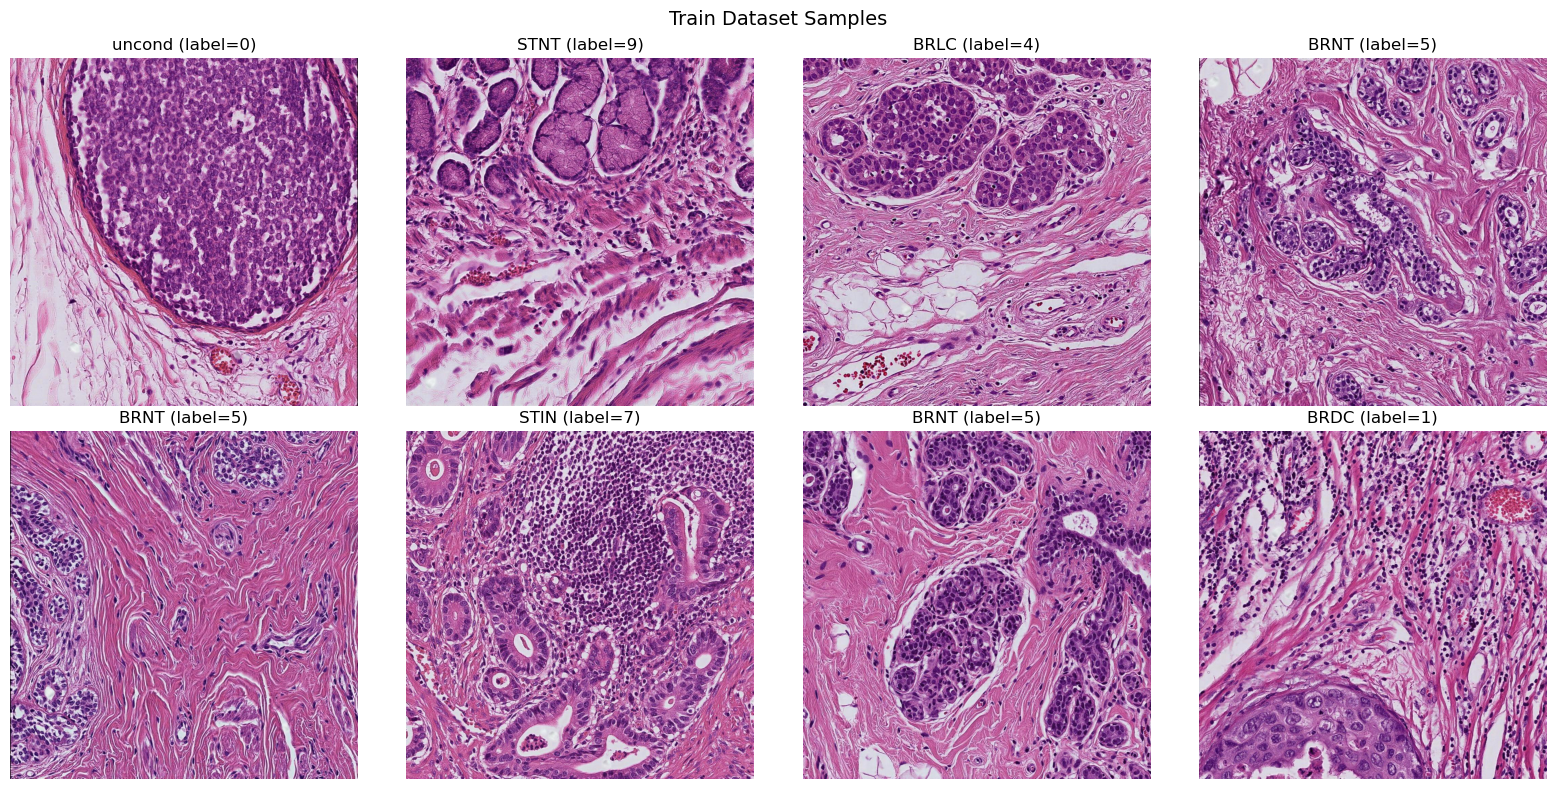

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(8):
    img, label = train_dataset[i * (len(train_dataset) // 8)]
    ax = axes[i // 4][i % 4]
    ax.imshow(img.permute(1, 2, 0).numpy())
    cls_name = [k for k, v in CLASS_TO_IDX.items() if v == label]
    cls_name = cls_name[0] if cls_name else "uncond"
    ax.set_title(f"{cls_name} (label={label})")
    ax.axis("off")
plt.suptitle("Train Dataset Samples", fontsize=14)
plt.tight_layout()
plt.show()

## 5. 모델 선언

### 구성
| 컴포넌트 | 구현 | 역할 |
|---|---|---|
| **VAE** | `stabilityai/sd-vae-ft-mse` (diffusers) | 이미지 ↔ latent 변환 (frozen) |
| **UNetModel** | `ldm.modules.diffusionmodules.openaimodel.UNetModel` | latent 공간 noise 예측 |
| **ClassEmbedder** | 인라인 구현 | 클래스 레이블 → cross-attention context |
| **DDPM Schedule** | `make_beta_schedule` (LDM) | noise schedule 관리 |

In [8]:
# ── DDPM Noise Schedule (LDM cin256 기본값) ──────────────────────────────────
betas = torch.tensor(
    make_beta_schedule("linear", TIMESTEPS, linear_start=LINEAR_START, linear_end=LINEAR_END),
    dtype=torch.float32,
)
alphas            = 1.0 - betas
alphas_cumprod    = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.ones(1), alphas_cumprod[:-1]])

sqrt_alphas_cumprod          = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas_cumprod    = torch.sqrt(1.0 / alphas_cumprod)
sqrt_recipm1_alphas_cumprod  = torch.sqrt(1.0 / alphas_cumprod - 1.0)

# GPU로 이동할 schedule 버퍼 (extract_into_tensor에서 사용)
def extract(a, t, x_shape):
    """timestep t에 해당하는 schedule 값을 추출 후 브로드캐스팅"""
    b = t.shape[0]
    out = a.to(t.device).gather(0, t)
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

print(f"Beta schedule: linear [{LINEAR_START}, {LINEAR_END}] over {TIMESTEPS} steps")
print(f"alphas_cumprod range: [{alphas_cumprod[-1]:.4f}, {alphas_cumprod[0]:.4f}]")

Beta schedule: linear [0.0015, 0.0195] over 1000 steps
alphas_cumprod range: [0.0001, 0.9985]


In [9]:
# ── ClassEmbedder (inline) ────────────────────────────────────────────────────
# LDM의 ClassEmbedder와 동일 구조 (clip 의존성 없이 직접 구현)
class ClassEmbedder(nn.Module):
    """클래스 레이블 → cross-attention context 벡터 [B, 1, embed_dim]"""

    def __init__(self, embed_dim, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(n_classes, embed_dim)

    def forward(self, labels):
        # labels: [B] (long) → [B, 1] → [B, 1, embed_dim]
        return self.embedding(labels.unsqueeze(1))


# ── LDM UNetModel ─────────────────────────────────────────────────────────────
# cin256 config 기반: image_size=32, channels=4, cross-attention으로 클래스 조건
unet = UNetModel(
    image_size=LATENT_SIZE,          # 32
    in_channels=LATENT_CHANNELS,     # 4
    out_channels=LATENT_CHANNELS,    # 4
    model_channels=MODEL_CHANNELS,   # 256
    attention_resolutions=list(ATTENTION_RESOLUTIONS),  # [4, 2, 1]
    num_res_blocks=NUM_RES_BLOCKS,   # 2
    channel_mult=list(CHANNEL_MULT), # [1, 2, 4]
    num_head_channels=NUM_HEAD_CHANNELS,  # 32
    use_spatial_transformer=True,    # cross-attention 사용
    transformer_depth=TRANSFORMER_DEPTH,  # 1
    context_dim=CONTEXT_DIM,         # 512
    use_checkpoint=True,             # gradient checkpointing (VRAM 절약)
)

# ── ClassEmbedder 인스턴스 ────────────────────────────────────────────────────
class_embedder = ClassEmbedder(
    embed_dim=CONTEXT_DIM,
    n_classes=N_EMBED,  # 0=uncond, 1~N=classes
)

# ── VAE (frozen) ─────────────────────────────────────────────────────────────
print("Loading VAE from stabilityai/sd-vae-ft-mse...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
embed_params = sum(p.numel() for p in class_embedder.parameters())
print(f"\nUNet trainable parameters: {total_params:,}")
print(f"ClassEmbedder parameters : {embed_params:,}")
print(f"Latent size              : {LATENT_SIZE}×{LATENT_SIZE}×{LATENT_CHANNELS}")
print(f"Context dim (CONTEXT_DIM): {CONTEXT_DIM}")
print(f"Num embeddings (classes+1): {N_EMBED}")

Loading VAE from stabilityai/sd-vae-ft-mse...

UNet trainable parameters: 387,092,996
ClassEmbedder parameters : 5,120
Latent size              : 128×128×4
Context dim (CONTEXT_DIM): 512
Num embeddings (classes+1): 10


## 6. 학습 설정 (Accelerator, Optimizer, Scheduler, EMA)

In [10]:
def cycle(dl):
    while True:
        for data in dl:
            yield data


# Accelerator
# LDM openaimodel의 GroupNorm/LayerNorm이 fp16/bf16 autocast와 호환되지 않아
# mixed_precision 비활성화. UNet의 use_checkpoint=True로 VRAM 절약.
accelerator = Accelerator(
    split_batches=True,
    mixed_precision="no",
    gradient_accumulation_steps=GRADIENT_ACCUMULATE_EVERY,
)

# 학습 대상 파라미터: UNet + ClassEmbedder
train_params = list(unet.parameters()) + list(class_embedder.parameters())
optimizer = AdamW(train_params, lr=LEARNING_RATE, betas=(0.9, 0.999))

scheduler = lr_scheduler.OneCycleLR(
    optimizer, max_lr=LEARNING_RATE, total_steps=TRAIN_NUM_STEPS
)

# EMA — LDM 자체 LitEma 사용
ema = LitEma(unet, decay=0.9999)

# Accelerator에 등록
unet, class_embedder, optimizer, scheduler, train_loader, val_loader = accelerator.prepare(
    unet, class_embedder, optimizer, scheduler, train_loader, val_loader
)
vae = accelerator.prepare(vae)
ema = ema.to(accelerator.device)

train_dl = cycle(train_loader)
val_dl   = cycle(val_loader)

print(f"Mixed precision : {accelerator.mixed_precision}")
print("Training setup complete!")

Mixed precision : no
Training setup complete!


## 7. 학습 함수 및 저장 함수 정의

In [11]:
def get_vae(vae_model):
    """accelerate wrapping 여부에 관계없이 실제 VAE 모듈 반환"""
    return vae_model.module if hasattr(vae_model, "module") else vae_model


def vae_encode(vae_model, imgs):
    """이미지 [0,1] → latent (scale 적용)"""
    imgs_norm = imgs * 2.0 - 1.0          # [-1, 1]
    posterior  = get_vae(vae_model).encode(imgs_norm)
    z = posterior.latent_dist.sample() * SCALE_FACTOR
    return z


def vae_decode(vae_model, z):
    """latent → 이미지 [0,1]"""
    decoded = get_vae(vae_model).decode(z / SCALE_FACTOR).sample  # [-1, 1]
    return torch.clamp((decoded + 1.0) / 2.0, 0.0, 1.0)


def q_sample(z, t, noise=None):
    """Forward process: z_t = sqrt(ᾱ_t)·z + sqrt(1-ᾱ_t)·ε"""
    if noise is None:
        noise = torch.randn_like(z)
    # 스케줄 텐서를 z와 동일한 dtype으로 캐스팅 (bf16 혼합 정밀도 대응)
    return (
        extract(sqrt_alphas_cumprod, t, z.shape).to(z.dtype) * z
        + extract(sqrt_one_minus_alphas_cumprod, t, z.shape).to(z.dtype) * noise
    )


def compute_loss(unet_model, embedder, z, labels):
    """DDPM L_simple (ε-prediction MSE loss)"""
    B = z.shape[0]
    t = torch.randint(0, TIMESTEPS, (B,), device=z.device).long()
    noise   = torch.randn_like(z)
    z_noisy = q_sample(z, t, noise)

    # ClassEmbedder: labels [B] → context [B, 1, CONTEXT_DIM]
    context = embedder(labels)

    eps_pred = unet_model(z_noisy, t, context=context)
    return F.mse_loss(eps_pred, noise)


@torch.no_grad()
def ddim_sample_images(unet_model, embedder, vae_model, labels, ddim_steps=50, eta=0.0):
    """
    DDIM 샘플링 (Song et al., 2020)
    - LitEma의 copy_to/store/restore 패턴으로 EMA 가중치 사용
    """
    B = labels.shape[0]
    device_ = labels.device

    context = embedder(labels)  # [B, 1, CONTEXT_DIM]

    step_size = TIMESTEPS // ddim_steps
    timesteps = list(reversed(range(0, TIMESTEPS, step_size)))

    z = torch.randn(B, LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE, device=device_)

    for i, t_val in enumerate(timesteps):
        t_batch = torch.full((B,), t_val, device=device_, dtype=torch.long)

        eps_pred = unet_model(z, t_batch, context=context)

        alpha_t      = alphas_cumprod[t_val].to(device_)
        t_prev_val   = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        alpha_t_prev = alphas_cumprod[t_prev_val].to(device_) if t_prev_val >= 0 else torch.ones(1, device=device_)

        z0_pred = (z - (1 - alpha_t).sqrt() * eps_pred) / alpha_t.sqrt()
        z0_pred = z0_pred.clamp(-1.0, 1.0)

        sigma  = eta * ((1 - alpha_t_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_t_prev)).sqrt()
        noise  = torch.randn_like(z) if (eta > 0 and i < len(timesteps) - 1) else torch.zeros_like(z)
        dir_xt = (1 - alpha_t_prev - sigma ** 2).sqrt() * eps_pred
        z = alpha_t_prev.sqrt() * z0_pred + dir_xt + sigma * noise

    return vae_decode(vae_model, z)


def save_checkpoint(step, milestone, running_loss, running_lr):
    data = {
        "step"      : step,
        "loss"      : running_loss,
        "lr"        : running_lr,
        "unet"      : accelerator.get_state_dict(unet),
        "embedder"  : accelerator.get_state_dict(class_embedder),
        "ema"       : ema.state_dict(),
        "opt"       : optimizer.state_dict(),
        "scheduler" : scheduler.state_dict(),
        "scaler"    : accelerator.scaler.state_dict() if accelerator.scaler else None,
        "config": {
            "image_size"      : IMAGE_SIZE,
            "latent_size"     : LATENT_SIZE,
            "model_channels"  : MODEL_CHANNELS,
            "channel_mult"    : CHANNEL_MULT,
            "context_dim"     : CONTEXT_DIM,
            "n_embed"         : N_EMBED,
            "class_to_idx"    : CLASS_TO_IDX,
            "scale_factor"    : SCALE_FACTOR,
        },
    }
    save_path = os.path.join(MODEL_SAVE_DIR, f"model-{milestone}.pt")
    torch.save(data, save_path)
    print(f"  Checkpoint saved: {save_path}")


def load_checkpoint(milestone):
    load_path = os.path.join(MODEL_SAVE_DIR, f"model-{milestone}.pt")
    data = torch.load(load_path, map_location=accelerator.device)

    accelerator.unwrap_model(unet).load_state_dict(data["unet"])
    accelerator.unwrap_model(class_embedder).load_state_dict(data["embedder"])
    ema.load_state_dict(data["ema"])
    optimizer.load_state_dict(data["opt"])
    scheduler.load_state_dict(data["scheduler"])
    if data.get("scaler") and accelerator.scaler:
        accelerator.scaler.load_state_dict(data["scaler"])

    print(f"  Checkpoint loaded from step {data['step']}")
    return data["step"], data.get("loss", []), data.get("lr", [])


def generate_and_save_samples(step):
    """EMA 가중치로 val 배치 샘플 생성 후 저장"""
    unet_unwrapped = accelerator.unwrap_model(unet)
    emb_unwrapped  = accelerator.unwrap_model(class_embedder)

    # EMA 가중치를 unet에 임시 복사
    ema.store(unet_unwrapped.parameters())
    ema.copy_to(unet_unwrapped)
    unet_unwrapped.eval()
    emb_unwrapped.eval()

    imgs, labels = next(val_dl)
    imgs   = imgs[:1]
    labels = torch.tensor(
        [labels[i].item() if labels[i].item() > 0 else 1 for i in range(1)],
        device=imgs.device, dtype=torch.long,
    )

    with torch.no_grad():
        samples = ddim_sample_images(
            unet_unwrapped, emb_unwrapped, vae, labels,
            ddim_steps=SAMPLING_TIMESTEPS,
        )

    # 원래 학습 가중치 복원
    ema.restore(unet_unwrapped.parameters())

    milestone = step // SAVE_SAMPLE_EVERY
    nrow = int(math.sqrt(NUM_SAMPLES))
    vutils.save_image(imgs,    os.path.join(RESULTS_DIR, f"original-{milestone}.png"), nrow=nrow)
    vutils.save_image(samples, os.path.join(RESULTS_DIR, f"sample-{milestone}.png"),   nrow=nrow)
    print(f"  Samples saved at step {step}")


print("Functions defined.")


Functions defined.


## 8. 학습 실행

체크포인트에서 이어서 학습하려면 `RESUME_MILESTONE`을 설정하세요.

In [12]:
RESUME_MILESTONE = 5   # 예: 3  (model-3.pt 에서 재개)

step = 0
running_loss = []
running_lr   = []

if RESUME_MILESTONE is not None:
    step, running_loss, running_lr = load_checkpoint(RESUME_MILESTONE)

with tqdm(initial=step, total=TRAIN_NUM_STEPS, disable=not accelerator.is_main_process) as pbar:
    while step < TRAIN_NUM_STEPS:
        total_loss = 0.0
        unet.train()
        class_embedder.train()

        for _ in range(GRADIENT_ACCUMULATE_EVERY):
            imgs, labels = next(train_dl)

            with accelerator.accumulate(unet):
                # 1. VAE encode: 이미지 → latent
                with torch.no_grad():
                    z = vae_encode(vae, imgs)

                # 2. DDPM loss (UNet + ClassEmbedder)
                loss = compute_loss(unet, class_embedder, z, labels)

                accelerator.backward(loss)
                accelerator.clip_grad_norm_(train_params, 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

                total_loss += loss.item()

        total_loss /= GRADIENT_ACCUMULATE_EVERY

        if step % SAVE_LOSS_EVERY == 0:
            running_loss.append(total_loss)
            running_lr.append(scheduler.get_last_lr()[0])

        pbar.set_description(f"loss: {total_loss:.4f}")

        # EMA 업데이트 — LitEma: ema(model) 호출
        if accelerator.is_main_process:
            ema(accelerator.unwrap_model(unet))

        step += 1

        # 샘플 생성 & 체크포인트 저장
        if step % SAVE_SAMPLE_EVERY == 0 and accelerator.is_main_process:
            milestone = step // SAVE_SAMPLE_EVERY
            print(f"\n--- Step {step} (Milestone {milestone}) ---")
            generate_and_save_samples(step)
            save_checkpoint(step, milestone, running_loss, running_lr)

        pbar.update(1)

print("Training complete!")

  Checkpoint loaded from step 25000


loss: 0.2293:  12%|█▏        | 29999/250000 [3:13:42<142:23:52,  2.33s/it]


--- Step 30000 (Milestone 6) ---
  Samples saved at step 30000


loss: 0.2293:  12%|█▏        | 30000/250000 [3:13:54<378:14:41,  6.19s/it]

  Checkpoint saved: ../../../model/NIPA/pathldm/model-6.pt


...


--- Step 175000 (Milestone 35) ---
  Samples saved at step 175000


loss: 0.0630:  70%|███████   | 175000/250000 [97:14:37<124:24:10,  5.97s/it]

  Checkpoint saved: ../../../model/NIPA/pathldm/model-35.pt


loss: 0.0982:  71%|███████   | 177706/250000 [98:59:33<46:51:53,  2.33s/it] 


KeyboardInterrupt: 

## 9. 학습 결과 시각화

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(running_loss)
ax1.set_title("Training Loss")
ax1.set_xlabel(f"Step (×{SAVE_LOSS_EVERY})")
ax1.set_ylabel("MSE Loss")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

ax2.plot(running_lr)
ax2.set_title("Learning Rate")
ax2.set_xlabel(f"Step (×{SAVE_LOSS_EVERY})")
ax2.set_ylabel("LR")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Final loss: {running_loss[-1]:.6f}" if running_loss else "No loss recorded yet")

## 10. 생성된 샘플 이미지 확인

In [ ]:
import matplotlib.pyplot as plt

sample_files   = sorted(glob(os.path.join(RESULTS_DIR, "sample-*.png")))
original_files = sorted(glob(os.path.join(RESULTS_DIR, "original-*.png")))

if sample_files and original_files:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(Image.open(original_files[-1]))
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(Image.open(sample_files[-1]))
    axes[1].set_title(f"Generated (Milestone {len(sample_files)})")
    axes[1].axis("off")
    plt.suptitle(f"PathLDM Sample (DDIM {SAMPLING_TIMESTEPS} steps)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No sample images found yet. Run training first.")

## 11. 클래스별 샘플 생성 (Classifier-Free Guidance)

In [ ]:
GUIDANCE_SCALE = 3.0   # w: 높을수록 클래스 조건이 강해짐
GEN_CLASS = 1          # 생성할 클래스 index (1 ~ NUM_CLASSES)
GEN_N = 4              # 생성 이미지 수


@torch.no_grad()
def ddim_sample_cfg(
    unet_model, embedder, vae_model,
    labels, guidance_scale=3.0, ddim_steps=50, eta=0.0,
):
    """Classifier-Free Guidance DDIM 샘플링"""
    B = labels.shape[0]
    device_ = labels.device

    # 조건/비조건 context 쌍
    uncond_labels = torch.zeros(B, dtype=torch.long, device=device_)
    context_cond   = embedder(labels)        # [B, 1, CONTEXT_DIM]
    context_uncond = embedder(uncond_labels)  # [B, 1, CONTEXT_DIM]
    context = torch.cat([context_uncond, context_cond], dim=0)  # [2B, 1, CONTEXT_DIM]

    step_size = TIMESTEPS // ddim_steps
    timesteps = list(reversed(range(0, TIMESTEPS, step_size)))

    z = torch.randn(B, LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE, device=device_)

    for i, t_val in enumerate(timesteps):
        t_batch = torch.full((B,), t_val, device=device_, dtype=torch.long)
        t_batch_2 = torch.cat([t_batch, t_batch], dim=0)  # [2B]
        z_2 = torch.cat([z, z], dim=0)                    # [2B, C, H, W]

        eps_both = unet_model(z_2, t_batch_2, context=context)
        eps_uncond, eps_cond = eps_both.chunk(2)

        # CFG: ε̃ = ε_uncond + w·(ε_cond - ε_uncond)
        eps_guided = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        alpha_t      = alphas_cumprod[t_val].to(device_)
        t_prev_val   = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        alpha_t_prev = alphas_cumprod[t_prev_val].to(device_) if t_prev_val >= 0 else torch.ones(1, device=device_)

        z0_pred = (z - (1 - alpha_t).sqrt() * eps_guided) / alpha_t.sqrt()
        z0_pred = z0_pred.clamp(-1.0, 1.0)

        sigma  = eta * ((1 - alpha_t_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_t_prev)).sqrt()
        noise  = torch.randn_like(z) if (eta > 0 and i < len(timesteps) - 1) else torch.zeros_like(z)
        dir_xt = (1 - alpha_t_prev - sigma ** 2).sqrt() * eps_guided
        z = alpha_t_prev.sqrt() * z0_pred + dir_xt + sigma * noise

    return vae_decode(vae_model, z)


# ── 생성 실행 ──────────────────────────────────────────────────────────────────
ema_raw  = accelerator.unwrap_model(ema)
ema_unet = ema_raw.ema_model if hasattr(ema_raw, "ema_model") else ema_raw
ema_unet.eval()
emb_raw = accelerator.unwrap_model(class_embedder)
emb_raw.eval()

gen_labels = torch.full((GEN_N,), GEN_CLASS, dtype=torch.long, device=accelerator.device)

gen_images = ddim_sample_cfg(
    ema_unet, emb_raw, vae,
    labels=gen_labels,
    guidance_scale=GUIDANCE_SCALE,
    ddim_steps=SAMPLING_TIMESTEPS,
)

cls_name = [k for k, v in CLASS_TO_IDX.items() if v == GEN_CLASS]
cls_name = cls_name[0] if cls_name else f"idx={GEN_CLASS}"

fig, axes = plt.subplots(1, GEN_N, figsize=(4 * GEN_N, 4))
for i in range(GEN_N):
    axes[i].imshow(gen_images[i].cpu().permute(1, 2, 0).numpy())
    axes[i].set_title(f"{cls_name}")
    axes[i].axis("off")
plt.suptitle(f"CFG (w={GUIDANCE_SCALE}) — class: {cls_name}", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"cfg_sample_{cls_name}.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. 최종 모델 저장

In [ ]:
final_data = {
    "step"     : step,
    "loss"     : running_loss,
    "lr"       : running_lr,
    "unet"     : accelerator.get_state_dict(unet),
    "embedder" : accelerator.get_state_dict(class_embedder),
    "ema"      : accelerator.get_state_dict(ema),
    "config": {
        "image_size"          : IMAGE_SIZE,
        "latent_size"         : LATENT_SIZE,
        "latent_channels"     : LATENT_CHANNELS,
        "scale_factor"        : SCALE_FACTOR,
        "model_channels"      : MODEL_CHANNELS,
        "channel_mult"        : CHANNEL_MULT,
        "attention_resolutions": ATTENTION_RESOLUTIONS,
        "num_res_blocks"      : NUM_RES_BLOCKS,
        "context_dim"         : CONTEXT_DIM,
        "transformer_depth"   : TRANSFORMER_DEPTH,
        "n_embed"             : N_EMBED,
        "timesteps"           : TIMESTEPS,
        "linear_start"        : LINEAR_START,
        "linear_end"          : LINEAR_END,
        "class_names"         : CLASS_NAMES,
        "class_to_idx"        : CLASS_TO_IDX,
    },
}

final_path = os.path.join(MODEL_SAVE_DIR, "model-final.pt")
torch.save(final_data, final_path)
print(f"Final model saved : {final_path}")
print(f"Total train steps : {step}")
print(f"Save directory    : {os.path.abspath(MODEL_SAVE_DIR)}")